# System Signals: Latency

Trực quan hóa độ trễ theo thời gian và đánh dấu checkpoint đầu tiên chạm ngưỡng cảnh báo **500 ms**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(54)
latency = np.array([
    85, 83, 92, 88, 105, 115, 113, 90, 75, 98, 92, 120,
    160, 125, 120, 135, 105, 115, 125, 95, 90, 105, 95, 115,
    110, 130, 165, 205, 210, 235, 190, 205, 180, 210, 255, 280,
    275, 310, 365, 390, 345, 385, 350, 390, 400, 475, 490, 540,
    620, 625, 650, 690, 675, 710
])

alert_threshold = 500
warning_threshold = 250
critical_threshold = 750

assert len(time) == len(latency)

In [2]:
crossing_indices = np.flatnonzero(latency >= alert_threshold)
checkpoint_index = int(crossing_indices[0]) if crossing_indices.size else None

if checkpoint_index is None:
    print(f"Latency chưa vượt ngưỡng {alert_threshold} ms.")
else:
    print(
        f"Alert checkpoint: time={time[checkpoint_index]}, "
        f"latency={latency[checkpoint_index]} ms"
    )

Alert checkpoint: time=47, latency=540 ms


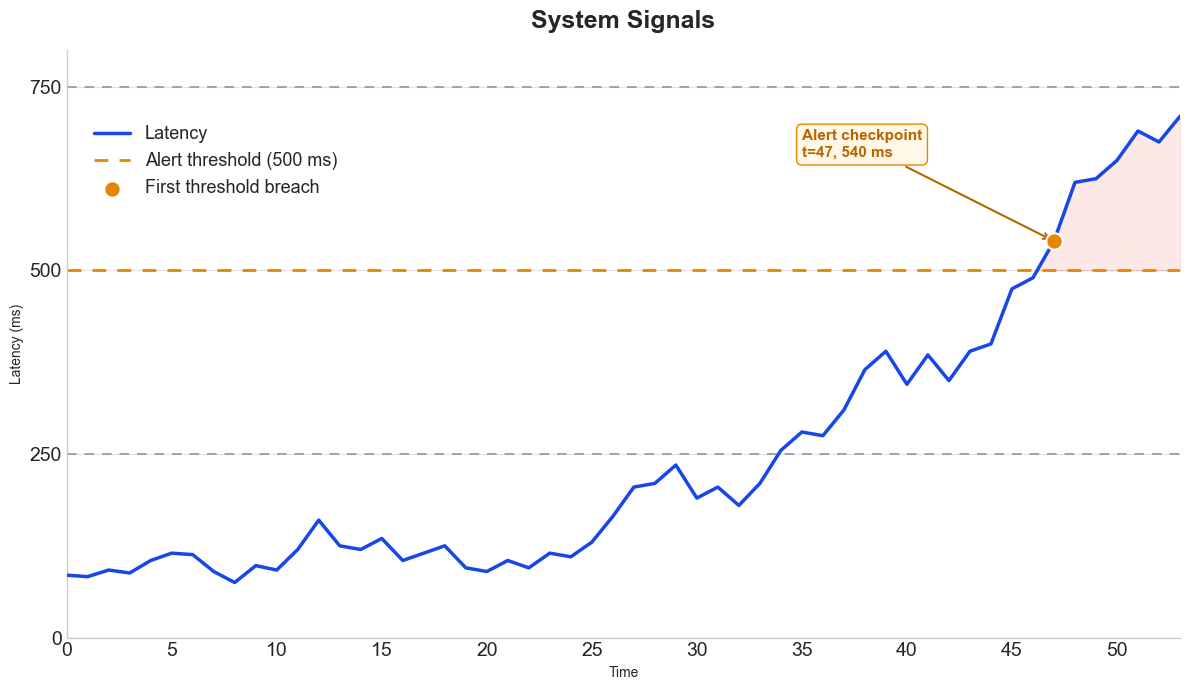

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    time, latency,
    color="#1747E8", linewidth=2.5,
    label="Latency", zorder=3,
)

ax.axhline(warning_threshold, color="#9CA3AF", linestyle=(0, (5, 4)), linewidth=1.4)
ax.axhline(alert_threshold, color="#E68600", linestyle=(0, (5, 4)), linewidth=2, label="Alert threshold (500 ms)")
ax.axhline(critical_threshold, color="#9CA3AF", linestyle=(0, (5, 4)), linewidth=1.4)

if checkpoint_index is not None:
    checkpoint_time = time[checkpoint_index]
    checkpoint_latency = latency[checkpoint_index]
    ax.scatter(
        checkpoint_time, checkpoint_latency,
        s=140, color="#E68600", edgecolor="white", linewidth=1.5,
        zorder=5, label="First threshold breach",
    )
    ax.annotate(
        f"Alert checkpoint\nt={checkpoint_time}, {checkpoint_latency} ms",
        xy=(checkpoint_time, checkpoint_latency),
        xytext=(checkpoint_time - 12, checkpoint_latency + 115),
        fontsize=11, color="#B86500", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#B86500", lw=1.5),
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#FFF7E8", edgecolor="#E68600"),
    )

ax.fill_between(
    time, alert_threshold, latency,
    where=latency >= alert_threshold,
    color="#EF4444", alpha=0.12, interpolate=True,
)

ax.set(
    title="System Signals",
    xlabel="Time",
    ylabel="Latency (ms)",
    xlim=(time.min(), time.max()),
    ylim=(0, 800),
)
ax.set_yticks([0, 250, 500, 750])
ax.set_xticks(np.arange(0, 54, 5))
ax.tick_params(axis="both", labelsize=14)
ax.set_title("System Signals", fontsize=18, fontweight="bold", pad=16)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", color="#D1D5DB", alpha=0.7)
ax.legend(loc="upper left", bbox_to_anchor=(0.01, 0.90), fontsize=13, frameon=False)
fig.tight_layout()
plt.show()